In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Генерація даних
from sklearn.datasets import make_classification

# Моделі
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Метрики та інструменти
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Налаштування стилю графіків
sns.set(style="whitegrid")

In [12]:
def train_and_evaluate(df, target_col, dataset_name):
    print(f"\n{'='*20} Аналіз набору даних: {dataset_name} {'='*20}")
    
    # 1. Розподіл на ознаки (X) та цільову змінну (y)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # 2. Розподіл на train/test (80% на навчання, 20% на тест)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 3. Масштабування даних (важливо для Logistic Regression)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Словник моделей
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Навчання
        model.fit(X_train, y_train)
        # Передбачення
        y_pred = model.predict(X_test)
        
        # Метрики
        acc = accuracy_score(y_test, y_pred)
        
        print(f"\n--- {name} ---")
        print(f"Accuracy: {acc:.4f}")
        # Виводимо детальний звіт. zero_division=0 прибирає зайві попередження
        print(classification_report(y_test, y_pred, zero_division=0))
        
        # === ВІЗУАЛІЗАЦІЯ (Матриця плутанини) ===
        plt.figure(figsize=(5, 4))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {name}')
        plt.ylabel('Справжній клас')
        plt.xlabel('Передбачений клас')
        plt.show()
        # ========================================
        
        results[name] = acc
        
    return results


>>> ЗАВДАННЯ 1: Синтетичні дані

==================== Аналіз набору даних: Synthetic Sklearn Data ====================

--- Logistic Regression ---
Accuracy: 0.7250
              precision    recall  f1-score   support

           0       0.70      0.73      0.71        55
           1       0.74      0.72      0.73        71
           2       0.73      0.73      0.73        74

    accuracy                           0.72       200
   macro avg       0.72      0.73      0.72       200
weighted avg       0.73      0.72      0.73       200



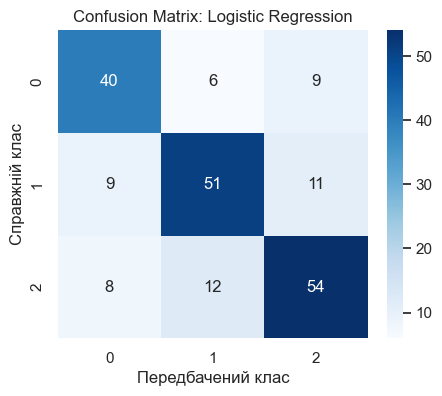


--- Decision Tree ---
Accuracy: 0.7850
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        55
           1       0.83      0.77      0.80        71
           2       0.78      0.80      0.79        74

    accuracy                           0.79       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.79      0.79      0.79       200



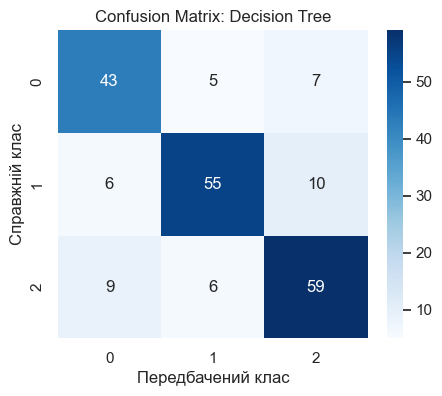


--- Random Forest ---
Accuracy: 0.8550
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        55
           1       0.88      0.83      0.86        71
           2       0.85      0.84      0.84        74

    accuracy                           0.85       200
   macro avg       0.85      0.86      0.86       200
weighted avg       0.86      0.85      0.85       200



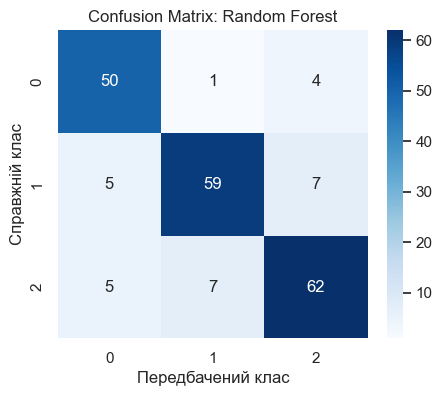

In [13]:
# --- ЗАВДАННЯ 1: Генерація синтетичних даних ---
print("\n>>> ЗАВДАННЯ 1: Синтетичні дані")

# Створення даних
X_synth, y_synth = make_classification(
    n_samples=1000, 
    n_features=10, 
    n_informative=5, 
    n_classes=3, 
    random_state=42
)

# Перетворення у DataFrame
df_synth = pd.DataFrame(X_synth, columns=[f'feature_{i}' for i in range(10)])
df_synth['target'] = y_synth

# Запуск аналізу
results_synth = train_and_evaluate(df_synth, 'target', "Synthetic Sklearn Data")


>>> ЗАВДАННЯ 2: Реальні дані (Fish Market)
Успішно завантажено: Fish.csv


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


Класи риб закодовано: ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']

==================== Аналіз набору даних: Fish Market Dataset ====================

--- Logistic Regression ---
Accuracy: 0.8750
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       0.69      1.00      0.82         9
           3       1.00      1.00      1.00         3
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         5
           6       0.00      0.00      0.00         3

    accuracy                           0.88        32
   macro avg       0.67      0.71      0.69        32
weighted avg       0.79      0.88      0.82        32



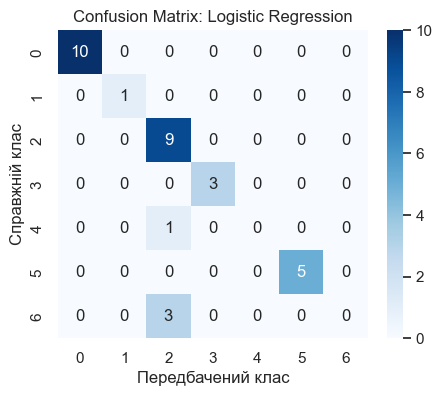


--- Decision Tree ---
Accuracy: 0.7812
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       1.00      0.44      0.62         9
           3       1.00      1.00      1.00         3
           4       0.12      1.00      0.22         1
           5       1.00      1.00      1.00         5
           6       1.00      0.33      0.50         3

    accuracy                           0.78        32
   macro avg       0.88      0.83      0.76        32
weighted avg       0.97      0.78      0.82        32



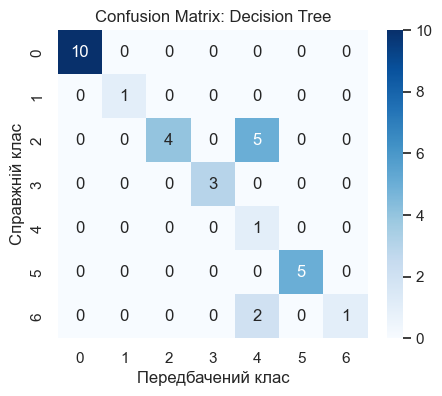


--- Random Forest ---
Accuracy: 0.7812
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       0.75      0.67      0.71         9
           3       1.00      1.00      1.00         3
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         5
           6       0.00      0.00      0.00         3

    accuracy                           0.78        32
   macro avg       0.68      0.67      0.67        32
weighted avg       0.80      0.78      0.79        32



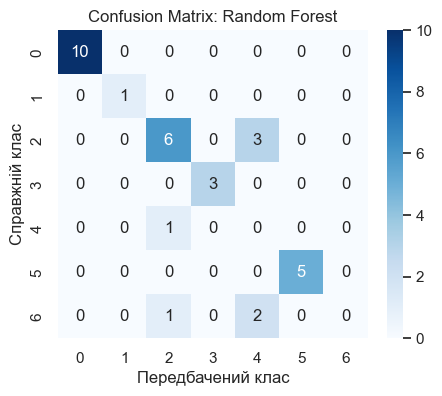

In [14]:
# --- ЗАВДАННЯ 2: Реальні дані (Fish Market) ---
print("\n>>> ЗАВДАННЯ 2: Реальні дані (Fish Market)")

file_name = 'Fish.csv' # Переконайся, що файл лежить поруч із ноутбуком

try:
    df_fish = pd.read_csv(file_name)
    print(f"Успішно завантажено: {file_name}")
    display(df_fish.head())
    
    # Перевірка на пропуски
    if df_fish.isnull().sum().sum() > 0:
        print("Знайдено пропуски, заповнюємо середнім...")
        df_fish = df_fish.fillna(df_fish.mean(numeric_only=True))
    
    # Кодування текстової колонки Species у числа (Perch -> 0, Pike -> 1...)
    le = LabelEncoder()
    df_fish['Species'] = le.fit_transform(df_fish['Species'])
    
    print(f"Класи риб закодовано: {le.classes_}")
    
    # Запуск аналізу (цільова колонка - Species)
    results_fish = train_and_evaluate(df_fish, 'Species', "Fish Market Dataset")

except FileNotFoundError:
    print(f"ПОМИЛКА: Файл {file_name} не знайдено! Переконайтеся, що він у папці Lab5.")

In [15]:
# --- БЛОК 4: Висновки ---
print("\n=== ПОРІВНЯННЯ ТОЧНОСТІ (ACCURACY) ===")
print(f"{'Dataset':<25} | {'LogReg':<10} | {'DecisionTree':<12} | {'RandomForest':<12}")
print("-" * 65)

# Виводимо результат 1-го завдання
if 'results_synth' in locals():
    print(f"{'Synthetic':<25} | {results_synth['Logistic Regression']:.4f}     | {results_synth['Decision Tree']:.4f}       | {results_synth['Random Forest']:.4f}")

# Виводимо результат 2-го завдання
if 'results_fish' in locals():
    print(f"{'Fish Market':<25} | {results_fish['Logistic Regression']:.4f}     | {results_fish['Decision Tree']:.4f}       | {results_fish['Random Forest']:.4f}")


=== ПОРІВНЯННЯ ТОЧНОСТІ (ACCURACY) ===
Dataset                   | LogReg     | DecisionTree | RandomForest
-----------------------------------------------------------------
Synthetic                 | 0.7250     | 0.7850       | 0.8550
Fish Market               | 0.8750     | 0.7812       | 0.7812
